In [ ]:
'''
NOTES:
- use BICUBIC, it produces cleaner images

TODO:
- calculate dataset mean color, and use that for padding
'''

'\nNOTES:\n- use BICUBIC, it produces cleaner images\n'

In [ ]:
from pathlib import Path
import random
from itertools import islice
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler,Subset, BatchSampler
from torchvision.datasets import ImageFolder
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as v2
from torchvision.transforms import InterpolationMode
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

# plt.rcParams["savefig.bbox"] = 'tight'
g = torch.Generator().manual_seed(123456789)
DATASET_ROOT = Path.cwd().parent / "data/processed/classification" 
BATCH_SIZE = 32

def seed():
  SEED = 123456789
  random.seed(SEED)
  np.random.seed(SEED)
  torch.manual_seed(SEED)
  torch.cuda.manual_seed(SEED)
  torch.cuda.manual_seed_all(SEED)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False # this also kills perfomance in focal loss, but verify it
  torch.use_deterministic_algorithms(True) # this kills performance when using focal loss

def show(imgs):
  if not isinstance(imgs, list):
    imgs = [imgs]
  fix, axs = plt.subplots(figsize=(18, 10), ncols=len(imgs), squeeze=False)
  for i, img in enumerate(imgs):
    # img = (img - img.min()) / (img.max() - img.min())
    img = F.to_pil_image(img)
    axs[0, i].imshow(np.asarray(img))
    axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

class PadToSquare:
  def __init__(self, padding_mode:str='edge', fill=0):
    self.fill = fill
    self.padding_mode = padding_mode

  def __call__(self, img):
    h, w = img.shape[-2:]
    max_wh = max(w, h)

    pad_left = (max_wh - w) // 2
    pad_right = max_wh - w - pad_left
    pad_top = (max_wh - h) // 2
    pad_bottom = max_wh - h - pad_top

    padding = [pad_left, pad_top, pad_right, pad_bottom]
    # return F.pad(img, padding, fill=self.fill)
    return v2.Pad(padding, padding_mode=self.padding_mode)(img)

SIZE = 32
interpolation = InterpolationMode.BICUBIC
transform = v2.Compose([
  v2.ToImage(),
  # v2.Pad(13, padding_mode='edge'),
  PadToSquare(),
  v2.Resize((SIZE, SIZE), interpolation=interpolation, antialias=True),
  v2.ToDtype(torch.float32, scale=True),
  # v2.Normalize(mean=[0.4291, 0.5388, 0.3654], std=[0.1859, 0.2121, 0.1966])
])

train_ds = ImageFolder(DATASET_ROOT / "train", transform=transform)
dev_ds = ImageFolder(DATASET_ROOT / "dev", transform=transform)

class_counts = np.bincount(train_ds.targets)
class_weights = 1.0 / class_counts
sample_weights = class_weights[train_ds.targets]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True, generator=g)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=12, generator=g)
dev_loader = DataLoader(dev_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=12, generator=g)

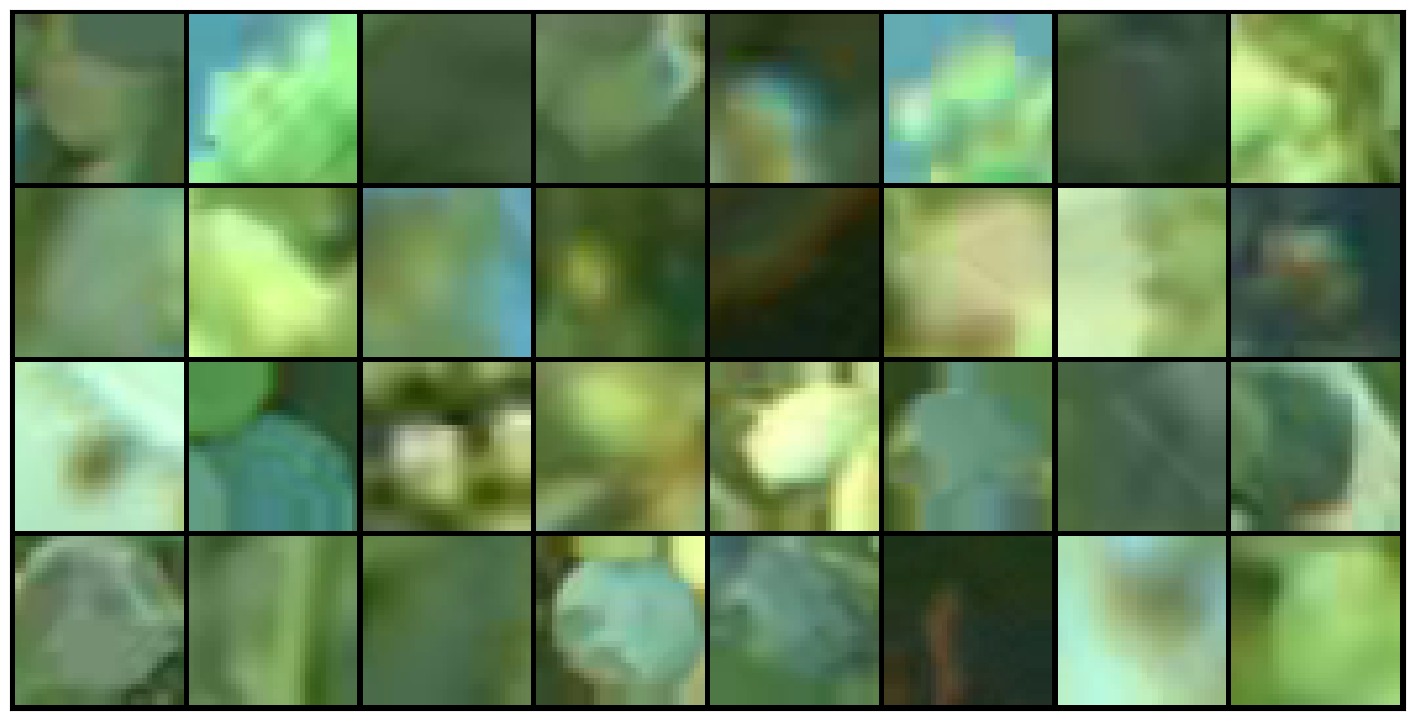

In [21]:
# seed()
IDX = 0 # which batch to get
vis_batch = next(islice(iter(train_loader), IDX, None))
vis_images, _ = vis_batch
grid = make_grid(vis_images, nrow=8, padding=1)

show(grid)